# Explore here

In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Buscamos el archivo CSV automáticamente
archivos = [f for f in os.listdir('.') if f.endswith('.csv')]
df = pd.read_csv(archivos[0]) 

X = df.drop(df.columns[-1], axis=1) 
# NÚCLEO: Forzamos a enteros para evitar el error 'continuous' en los modelos
y = df[df.columns[-1]].round().astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Archivo cargado: {archivos[0]}")

Archivo cargado: diabetes.csv


En este bloque se realiza la ingesta del dataset procesado en el EDA y se divide en conjuntos de entrenamiento y prueba (X y y).

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree_model.predict(X_test))
print(f"Precisión Árbol: {acc_tree:.4f}")

Precisión Árbol: 0.3500


Se entrena un Árbol de Decisión como modelo de referencia inicial

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Precisión Random Forest: {acc_rf:.4f}")

Precisión Random Forest: 0.5000


Implementamos Random Forest (técnica de Bagging) para reducir la varianza del modelo anterior.

In [4]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
acc_xgb = accuracy_score(y_test, xgb_model.predict(X_test))
print(f"Precisión XGBoost: {acc_xgb:.4f}")

Precisión XGBoost: 0.6000


Se aplica XGBoost como técnica de potenciación. A diferencia del bloque anterior, aquí los árboles se construyen de forma secuencial para corregir los errores del modelo previo.

In [5]:
import pickle
filename = "xgb_model_diabetes.sav"
pickle.dump(xgb_model, open(filename, "wb"))
print("Modelo XGBoost guardado exitosamente.")

Modelo XGBoost guardado exitosamente.


Se utiliza la librería pickle para exportar el modelo final entrenado a un archivo .sav

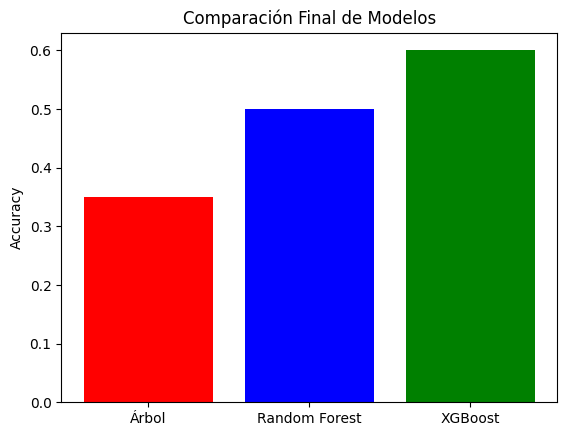

El modelo con mayor precisión es: XGBoost


In [6]:
import matplotlib.pyplot as plt

modelos = ['Árbol', 'Random Forest', 'XGBoost']
scores = [acc_tree, acc_rf, acc_xgb]

plt.bar(modelos, scores, color=['red', 'blue', 'green'])
plt.ylabel('Accuracy')
plt.title('Comparación Final de Modelos')
plt.show()

print(f"El modelo con mayor precisión es: {modelos[scores.index(max(scores))]}")

Tras comparar el rendimiento de los tres algoritmos, se identifica visualmente cuál ofrece la mayor precisión.